# Modelacion de Calidad del Aire con Hidden Markov Model (HMM)
## Zona Metropolitana de Guadalajara â€” Sensores D (Zapopan)

Este notebook implementa un **Hidden Markov Model (HMM)** para modelar la calidad del aire
como un proceso latente. La hipotesis central es que el estado real de la atmosfera â€”limpia,
afectada por trafico, fotoquimica activa, episodio de contaminacionâ€” es una **variable oculta**
que nunca se observa directamente, sino que se infiere de las mediciones de los sensores.

### Diferencia con el approach de regresion (modelacion.ipynb)
El notebook anterior predia el AQI directamente como regresion supervisada. Este notebook
trata la calidad del aire como un **sistema dinamico con estados discretos latentes**:

- Los estados ocultos Z(t) âˆˆ {1, ..., K} representan regimenes atmosfericos.
- Las observaciones X(t) = [CO, NO2, PM2.5, O3, SO2, TVOC] son las mediciones del sensor.
- El modelo aprende de forma **no supervisada** que combinacion quimica corresponde a cada regimen.
- La prediccion a futuro se hace proyectando la distribucion de estados con la matriz de transicion.

### ¿Por que HMM y no solo clustering?
El clustering (K-Means, GMM) asigna cada punto a un estado sin considerar la secuencia temporal.
El HMM incorpora explicitamente la dinamica: P(Z_t+1 | Z_t), la probabilidad de que el sistema
pase de un regimen a otro. Esto permite prediccion multi-step y captura la persistencia temporal
de los episodios de contaminacion.

In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from hmmlearn import hmm
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10
})

# Constantes del proyecto
SENSORES_D = ['D_P1', 'D_P2']
OBSERVATION_FEATURES = ['CO_ppm', 'NO2_ppm', 'PM2_5_ugm3', 'O3_ppm', 'SO2_ppm', 'TVOC_ppb']

# Frecuencia aproximada de cada sensor (minutos por registro)
FREQ_MIN = {'D_P1': 1.02, 'D_P2': 1.57}

# Horizontes de prediccion en pasos (ceil(minutos / freq))
H_30 = {s: int(np.ceil(30 / f)) for s, f in FREQ_MIN.items()}  # D_P1: 30, D_P2: 20
H_60 = {s: int(np.ceil(60 / f)) for s, f in FREQ_MIN.items()}  # D_P1: 59, D_P2: 39

print("Horizontes de prediccion (pasos):")
for s in SENSORES_D:
    print(f"  {s}: t+30min â†’ {H_30[s]} pasos | t+60min â†’ {H_60[s]} pasos")

Horizontes de prediccion (pasos):
  D_P1: t+30min â†’ 30 pasos | t+60min â†’ 59 pasos
  D_P2: t+30min â†’ 20 pasos | t+60min â†’ 39 pasos


---
## 1. Carga de Datos

Los datos provienen de `Datos_maestro_sensores.xlsx`. Se filtra unicamente a los sensores D
(`D_P1` y `D_P2`), que son los sensores de referencia del proyecto con mediciones completas
de todos los contaminantes criterio.

**¿Por que leer el Excel y no los CSVs del ETL?**
El ETL anterior transformo los contaminantes a escala logaritmica y no guardo todas las columnas.
Para el HMM necesitamos los valores en **escala original** (ppm, µg/m³) porque:
1. Las medias de emision μ_k deben ser interpretables quimicamente (ej. "CO = 0.8 ppm en trafico").
2. PM2.5, NO2 y O3 no se incluyeron como features en el ETL previo.
3. La normalizacion se aplica internamente con un StandardScaler, sin perder la referencia fisica.

In [126]:
df_raw = pd.read_excel('Data/Datos_maestro_sensores.xlsx', parse_dates=['datetime'])

# Filtrar a sensores D
df = df_raw[df_raw['sensor_periodo'].isin(SENSORES_D)].copy()
df = df.sort_values(['sensor_periodo', 'datetime']).reset_index(drop=True)

print(f"Registros totales: {len(df)}")
print(f"\nRegistros por sensor:")
print(df['sensor_periodo'].value_counts())
print(f"\nColumnas disponibles: {list(df.columns)}")

Registros totales: 13758

Registros por sensor:
sensor_periodo
D_P2    7550
D_P1    6208
Name: count, dtype: int64

Columnas disponibles: ['sensor_periodo', 'datetime', 'CO2_ppm', 'TVOC_ppb', 'AQI', 'CO_ppm', 'SO2_ppm', 'O3_ppm', 'NO2_ppm', 'PM2_5_ugm3', 'PM10_ugm3', 'temp_C', 'hum_pct', 'Bat_pct']


In [127]:
cols_necesarias = OBSERVATION_FEATURES + ['datetime', 'sensor_periodo', 'AQI']
faltantes = [c for c in cols_necesarias if c not in df.columns]
assert len(faltantes) == 0, f"Columnas faltantes: {faltantes}"

print("Verificacion OK â€” todas las columnas necesarias presentes")
print(f"\nRango temporal:")
for s in SENSORES_D:
    sub = df[df['sensor_periodo'] == s]
    print(f"  {s}: {sub['datetime'].min().date()} â†’ {sub['datetime'].max().date()} ({len(sub)} registros)")

Verificacion OK â€” todas las columnas necesarias presentes

Rango temporal:
  D_P1: 2025-11-06 â†’ 2025-11-11 (6208 registros)
  D_P2: 2025-11-13 â†’ 2025-11-25 (7550 registros)


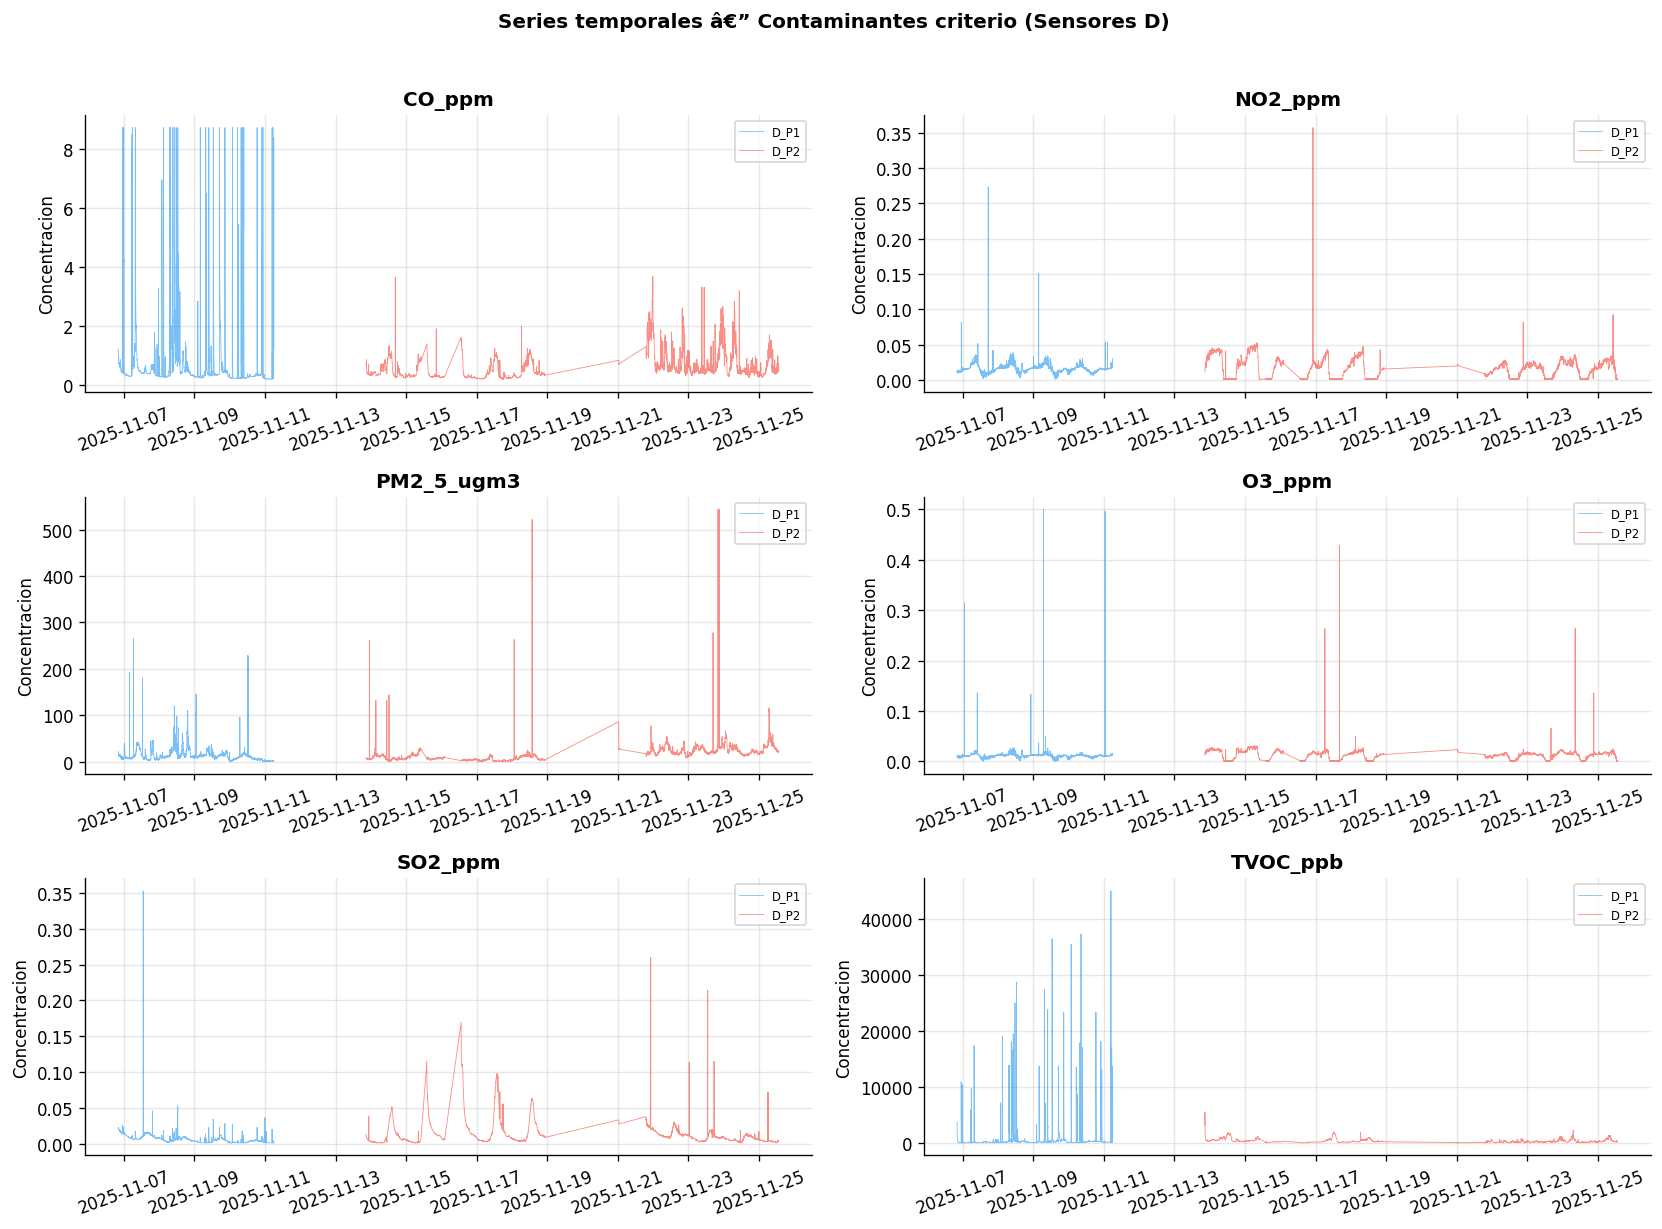


Estadisticas descriptivas:


,CO_ppm,NO2_ppm,PM2_5_ugm3,O3_ppm,SO2_ppm,TVOC_ppb
count,13758.0000,13758.0000,13758.0000,13758.0000,13758.0000,13758.0000
mean,0.7225,0.0166,14.9051,0.0124,0.0102,470.9973
std,1.1251,0.0114,15.7659,0.0112,0.0142,1719.8389
min,0.2008,0.0005,1.0000,0.0005,0.0011,0.0000
25%,0.3090,0.0101,6.0000,0.0092,0.0034,94.7675
50%,0.4190,0.0159,12.0000,0.0122,0.0065,178.0050
75%,0.6573,0.0218,20.0000,0.0148,0.0118,341.8900
max,8.7290,0.3571,544.0000,0.5002,0.3530,44927.8900


In [128]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

colores = {'D_P1': '#2196F3', 'D_P2': '#F44336'}

for i, feat in enumerate(OBSERVATION_FEATURES):
    for s in SENSORES_D:
        sub = df[df['sensor_periodo'] == s].set_index('datetime')
        axes[i].plot(sub.index, sub[feat], alpha=0.6, linewidth=0.5,
                     color=colores[s], label=s)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_ylabel('Concentracion')
    axes[i].legend(fontsize=7)
    axes[i].tick_params(axis='x', rotation=20)

plt.suptitle('Series temporales â€” Contaminantes criterio (Sensores D)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Data/HMM_01_series_contaminantes.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nEstadisticas descriptivas:")
display(df[OBSERVATION_FEATURES].describe().round(4))

---
## 2. Preprocesamiento

### 2.1 Segmentacion por gaps

El HMM **asume que los datos son una secuencia temporal continua**. Si hay una brecha
(por ejemplo, el sensor apagado 50 horas), el modelo interpretaria el salto como una
transicion de estado normal, lo que contamina la estimacion de la matriz de transicion A.

Solucion: identificar gaps > 5 minutos y cortar la serie en segmentos independientes.
Cada segmento es una secuencia continua. Al entrenar, se declaran sus longitudes por
separado en el parametro `lengths` de hmmlearn.

**Gaps por sensor:**
- D_P1: 0 gaps > 5 min â†’ completamente continuo (un solo segmento)
- D_P2: 4 gaps > 5 min, el mayor de ~50 horas (apagon 19-20 Nov)

In [129]:
def segmentar_por_gaps(df_sensor, umbral_min=5):
    """
    Divide la serie de un sensor en segmentos continuos.
    Un gap > umbral_min minutos rompe la continuidad.
    Retorna el DataFrame con columna 'segment_id' anadida.
    """
    sub = df_sensor.copy().sort_values('datetime').reset_index(drop=True)
    diffs = sub['datetime'].diff().dt.total_seconds() / 60
    sub['gap_min'] = diffs.fillna(0)
    sub['gap_flag'] = sub['gap_min'] > umbral_min
    sub['segment_id'] = sub['gap_flag'].cumsum()
    return sub

# Aplicar por sensor
df_list = []
for s in SENSORES_D:
    sub = df[df['sensor_periodo'] == s].copy()
    sub = segmentar_por_gaps(sub, umbral_min=5)
    df_list.append(sub)

df = pd.concat(df_list).sort_values(['sensor_periodo', 'datetime']).reset_index(drop=True)

# Hacer que segment_id sea unico a traves de sensores
df['segment_global_id'] = df['sensor_periodo'] + '_seg' + df['segment_id'].astype(str)

print("Segmentos por sensor:")
for s in SENSORES_D:
    sub = df[df['sensor_periodo'] == s]
    n_segs = sub['segment_id'].nunique()
    print(f"  {s}: {n_segs} segmento(s)")
    for seg_id, grp in sub.groupby('segment_id'):
        print(f"    Seg {seg_id}: {grp['datetime'].min().date()} â†’ "
              f"{grp['datetime'].max().date()} ({len(grp)} registros)")

Segmentos por sensor:
  D_P1: 1 segmento(s)
    Seg 0: 2025-11-06 â†’ 2025-11-11 (6208 registros)
  D_P2: 5 segmento(s)
    Seg 0: 2025-11-13 â†’ 2025-11-15 (1433 registros)
    Seg 1: 2025-11-15 â†’ 2025-11-16 (462 registros)
    Seg 2: 2025-11-16 â†’ 2025-11-18 (2187 registros)
    Seg 3: 2025-11-21 â†’ 2025-11-21 (9 registros)
    Seg 4: 2025-11-21 â†’ 2025-11-25 (3459 registros)


In [130]:
n_nan = df[OBSERVATION_FEATURES].isna().sum()
print("NaN por feature:")
print(n_nan)

if n_nan.sum() > 0:
    print("\nImputando NaN con forward fill + backward fill por segmento...")
    def fill_segment(grp):
        grp[OBSERVATION_FEATURES] = grp[OBSERVATION_FEATURES].ffill().bfill()
        return grp
    df = df.groupby('segment_global_id', group_keys=False).apply(fill_segment)
    print(f"NaN restantes: {df[OBSERVATION_FEATURES].isna().sum().sum()}")
else:
    print("Sin NaN â€” OK")

NaN por feature:
CO_ppm        0
NO2_ppm       0
PM2_5_ugm3    0
O3_ppm        0
SO2_ppm       0
TVOC_ppb      0
dtype: int64
Sin NaN â€” OK


### 2.2 Split temporal

El split se hace por fecha, no aleatoriamente, para simular prediccion real:
los datos anteriores al percentil 80 del tiempo son train, el resto es test.

**Importante:** El split respeta los segmentos â€” no se parte un segmento a la mitad
si no es necesario. En la practica, el percentil 80 cae dentro de D_P2 (que es el
sensor con mas datos y cubre hasta el 25 Nov).

In [131]:
# Cutoff temporal global en el percentil 80 del rango de fechas
t_min = df['datetime'].min()
t_max = df['datetime'].max()
cutoff = t_min + (t_max - t_min) * 0.8

df_train = df[df['datetime'] <= cutoff].copy()
df_test  = df[df['datetime'] >  cutoff].copy()

print(f"Cutoff temporal: {cutoff.strftime('%Y-%m-%d %H:%M')}")
print(f"Train: {len(df_train)} registros ({df_train['datetime'].min().date()} â†’ {df_train['datetime'].max().date()})")
print(f"Test:  {len(df_test)} registros ({df_test['datetime'].min().date()} â†’ {df_test['datetime'].max().date()})")

Cutoff temporal: 2025-11-21 19:33
Train: 10316 registros (2025-11-06 â†’ 2025-11-21)
Test:  3442 registros (2025-11-21 â†’ 2025-11-25)


In [132]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(df_train[OBSERVATION_FEATURES].values)
X_test_scaled  = scaler.transform(df_test[OBSERVATION_FEATURES].values)

print("Scaler ajustado sobre train.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape:  {X_test_scaled.shape}")

Scaler ajustado sobre train.
X_train_scaled shape: (10316, 6)
X_test_scaled shape:  (3442, 6)


### 2.3 El parametro `lengths` en hmmlearn

`GaussianHMM.fit(X, lengths=[n1, n2, ...])` indica que X es en realidad
la concatenacion de n1+n2+... observaciones de secuencias independientes.
Sin `lengths`, hmmlearn asume que toda la secuencia es continua y calculara
probabilidades de transicion incorrectas entre segmentos.

In [133]:
def calcular_lengths(df_split):
    """
    Calcula la longitud de cada segmento continuo dentro de un split.
    Retorna lista de enteros para el parametro lengths de hmmlearn.
    """
    lengths = []
    for seg_id, grp in df_split.groupby('segment_global_id', sort=False):
        lengths.append(len(grp))
    return lengths

lengths_train = calcular_lengths(df_train)
lengths_test  = calcular_lengths(df_test)

print(f"Segmentos en train: {len(lengths_train)} â†’ lengths: {lengths_train}")
print(f"Segmentos en test:  {len(lengths_test)} â†’ lengths: {lengths_test}")
assert sum(lengths_train) == len(df_train), "lengths_train no suma al total de filas"
assert sum(lengths_test)  == len(df_test),  "lengths_test no suma al total de filas"
print("Verificacion de lengths OK")

Segmentos en train: 6 â†’ lengths: [6208, 1433, 462, 2187, 9, 17]
Segmentos en test:  1 â†’ lengths: [3442]
Verificacion de lengths OK


---
## 3. SelecciÃ³n del NÃºmero de Estados K

### Â¿CuÃ¡ntos regÃ­menes de calidad del aire existen?

El HMM requiere especificar K (nÃºmero de estados ocultos) a priori. Para elegirlo de forma
objetiva usamos el **Criterio de InformaciÃ³n Bayesiano (BIC)**:

$$BIC = -2 \cdot \log(L) + p \cdot \log(n)$$

Donde:
- $\log(L)$ es la log-verosimilitud del modelo ajustado (mayor = mejor ajuste)
- $p$ es el nÃºmero de parÃ¡metros libres (penalizaciÃ³n por complejidad)
- $n$ es el nÃºmero de observaciones

El BIC penaliza modelos con mÃ¡s parÃ¡metros para evitar sobreajuste. Se elige el K que
**minimiza** el BIC.

**ParÃ¡metros libres de GaussianHMM con covariance_type='full':**
- Matriz de transiciÃ³n A: KÃ—(Kâˆ’1) parÃ¡metros (cada fila suma 1)
- Medias de emisiÃ³n Î¼_k: K Ã— n_features
- Matrices de covarianza Î£_k (full): K Ã— n_featuresÂ² parÃ¡metros

Se prueban K = 2, 3, 4, 5, 6, 7, 8.

In [134]:
def calcular_bic(X, lengths, k):
    """
    Entrena un GaussianHMM con k estados y calcula su BIC sobre X.
    Retorna (bic, modelo_entrenado).
    Usa covariance_type='diag' para reducir parametros libres y evitar sobreajuste.
    """
    modelo = hmm.GaussianHMM(
        n_components=k,
        covariance_type='diag',
        n_iter=100,
        random_state=42,
        verbose=False
    )
    modelo.fit(X, lengths=lengths)

    log_likelihood = modelo.score(X, lengths=lengths)
    n_features = X.shape[1]

    # Parametros libres con covariance_type='diag'
    # Covarianza diagonal: solo varianza por feature por estado (n_features params, no n_features^2)
    n_params = (k * (k - 1) +   # matriz de transicion
                k * n_features + # medias
                k * n_features)  # varianzas diagonales (antes: k * n_features**2 con 'full')

    bic = -2 * log_likelihood + n_params * np.log(len(X))
    return bic, modelo


In [135]:
print("Calculando BIC para K = 2..8 (puede tardar ~2-3 min)...")
resultados_bic = {}

for k in range(2, 9):
    bic, modelo_k = calcular_bic(X_train_scaled, lengths_train, k)
    resultados_bic[k] = {'bic': bic, 'modelo': modelo_k}
    print(f"  K={k} → BIC={bic:.2f}")

K_optimo = min(resultados_bic, key=lambda k: resultados_bic[k]['bic'])
print(f"K óptimo (BIC mínimo): K={K_optimo}")

# Override manual: forzar K=4 para evaluar generalización
K_optimo = 4
print(f"K override manual: K={K_optimo} (el BIC eligió K=8 pero se fuerza K=4 para comparación)")


Calculando BIC para K = 2..8 (puede tardar ~2-3 min)...
  K=2 → BIC=106183.73
  K=3 → BIC=55005.67


Model is not converging.  Current: -23120.994583155603 is not greater than -23120.987882473568. Delta is -0.006700682035443606


  K=4 → BIC=46796.50
  K=5 → BIC=15235.25
  K=6 → BIC=1293.53
  K=7 → BIC=-998.79
  K=8 → BIC=-17794.93
K óptimo (BIC mínimo): K=8
K override manual: K=4 (el BIC eligió K=8 pero se fuerza K=4 para comparación)


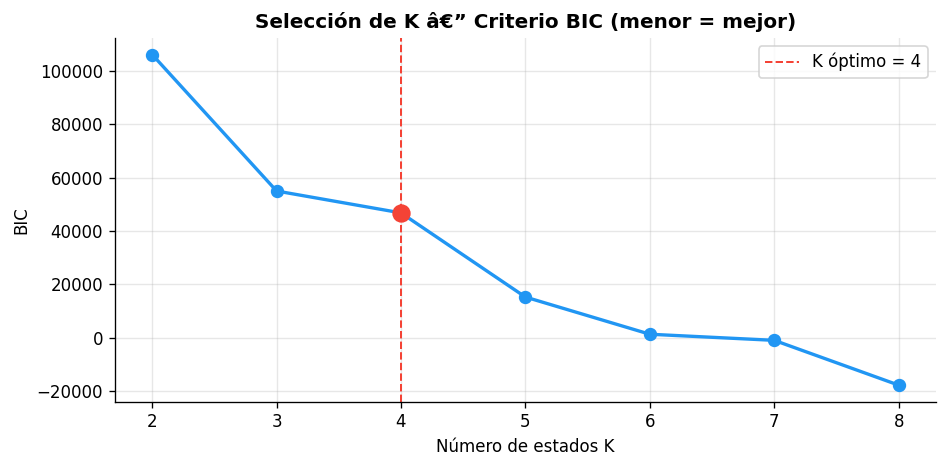

In [136]:
ks   = list(resultados_bic.keys())
bics = [resultados_bic[k]['bic'] for k in ks]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ks, bics, marker='o', color='#2196F3', linewidth=2, markersize=7)
ax.axvline(K_optimo, color='#F44336', linestyle='--', linewidth=1.2,
           label=f'K óptimo = {K_optimo}')
ax.scatter([K_optimo], [resultados_bic[K_optimo]['bic']],
           color='#F44336', s=100, zorder=5)
ax.set_xlabel('Número de estados K')
ax.set_ylabel('BIC')
ax.set_title('Selección de K â€” Criterio BIC (menor = mejor)', fontweight='bold')
ax.legend()
ax.set_xticks(ks)

plt.tight_layout()
plt.savefig('Data/HMM_02_bic_vs_k.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 4. Entrenamiento del GaussianHMM Final

Con K={K_optimo} estados seleccionado por BIC, se usa el modelo ya entrenado en el loop anterior
(no es necesario re-entrenar). Se reportan los parámetros aprendidos:

- **π** — distribución de estado inicial
- **A** — matriz de transición K×K
- **μ_k** — media de observaciones en estado k (en espacio normalizado y original)

In [137]:
model = resultados_bic[K_optimo]['modelo']

print(f"=== GaussianHMM con K={K_optimo} estados ===")
print(f"\nDistribución inicial π:")
for k in range(K_optimo):
    print(f"  Estado {k+1}: {model.startprob_[k]*100:.1f}%")

print(f"\nMatriz de transición A (filas = estado actual, cols = estado siguiente):")
A_df = pd.DataFrame(
    model.transmat_.round(3),
    index=[f'Z={k+1}' for k in range(K_optimo)],
    columns=[f'→Z={k+1}' for k in range(K_optimo)]
)
display(A_df)

print(f"\nLog-likelihood en train: {model.score(X_train_scaled, lengths=lengths_train):.2f}")

=== GaussianHMM con K=4 estados ===

Distribución inicial π:
  Estado 1: 33.3%
  Estado 2: 0.0%
  Estado 3: 66.7%
  Estado 4: 0.0%

Matriz de transición A (filas = estado actual, cols = estado siguiente):


,→Z=1,→Z=2,→Z=3,→Z=4
Z=1,0.993,0.005,0.001,0.001
Z=2,0.000,0.990,0.008,0.002
Z=3,0.003,0.036,0.960,0.000
Z=4,0.058,0.942,0.000,0.000



Log-likelihood en train: -23121.01


In [138]:
# Desnormalizar las medias para interpretación química
means_original = scaler.inverse_transform(model.means_)

df_medias = pd.DataFrame(
    means_original,
    columns=OBSERVATION_FEATURES,
    index=[f'Estado {k+1}' for k in range(K_optimo)]
)

print("\nMedias de emisión por estado (escala original):")
display(df_medias.round(4))
print("\nInterpretación química esperada:")
print("  CO alto + NO2 alto + TVOC alto → régimen de tráfico")
print("  O3 alto + NO2 bajo             → régimen fotoquímico")
print("  Todos bajos                    → aire limpio")
print("  PM2.5 alto + CO moderado       → episodio mixto/quemas")


Medias de emisión por estado (escala original):


,CO_ppm,NO2_ppm,PM2_5_ugm3,O3_ppm,SO2_ppm,TVOC_ppb
Estado 1,0.6292,0.0013,7.0389,0.0024,0.0387,526.3291
Estado 2,0.3571,0.0185,10.7216,0.0133,0.0060,177.8164
Estado 3,2.4820,0.0226,17.1460,0.0151,0.0075,2327.4952
Estado 4,0.3568,0.0778,9.7926,0.1706,0.0149,153.1247



Interpretación química esperada:
  CO alto + NO2 alto + TVOC alto → régimen de tráfico
  O3 alto + NO2 bajo             → régimen fotoquímico
  Todos bajos                    → aire limpio
  PM2.5 alto + CO moderado       → episodio mixto/quemas


---
## 5. Decodificación de Estados (Algoritmo de Viterbi)

El algoritmo de Viterbi encuentra la secuencia de estados ocultos más probable dada
la secuencia de observaciones: argmax P(Z_0:T | X_0:T).

También se calculan las **probabilidades posteriores** P(Z_t = k | X_0:t) con el
algoritmo forward, que es la entrada para la predicción multi-step.

In [139]:
# Decodificación por Viterbi
estados_test = model.predict(X_test_scaled, lengths=lengths_test)

# Probabilidades posteriores (algoritmo forward)
log_probs, posteriors_test = model.score_samples(X_test_scaled, lengths=lengths_test)

print(f"Estados decodificados: {len(estados_test)} timesteps")
print(f"\nDistribución de estados en test:")
for k in range(K_optimo):
    pct = (estados_test == k).mean() * 100
    print(f"  Estado {k+1}: {pct:.1f}% del tiempo")

Estados decodificados: 3442 timesteps

Distribución de estados en test:
  Estado 1: 18.3% del tiempo
  Estado 2: 52.7% del tiempo
  Estado 3: 28.7% del tiempo
  Estado 4: 0.3% del tiempo


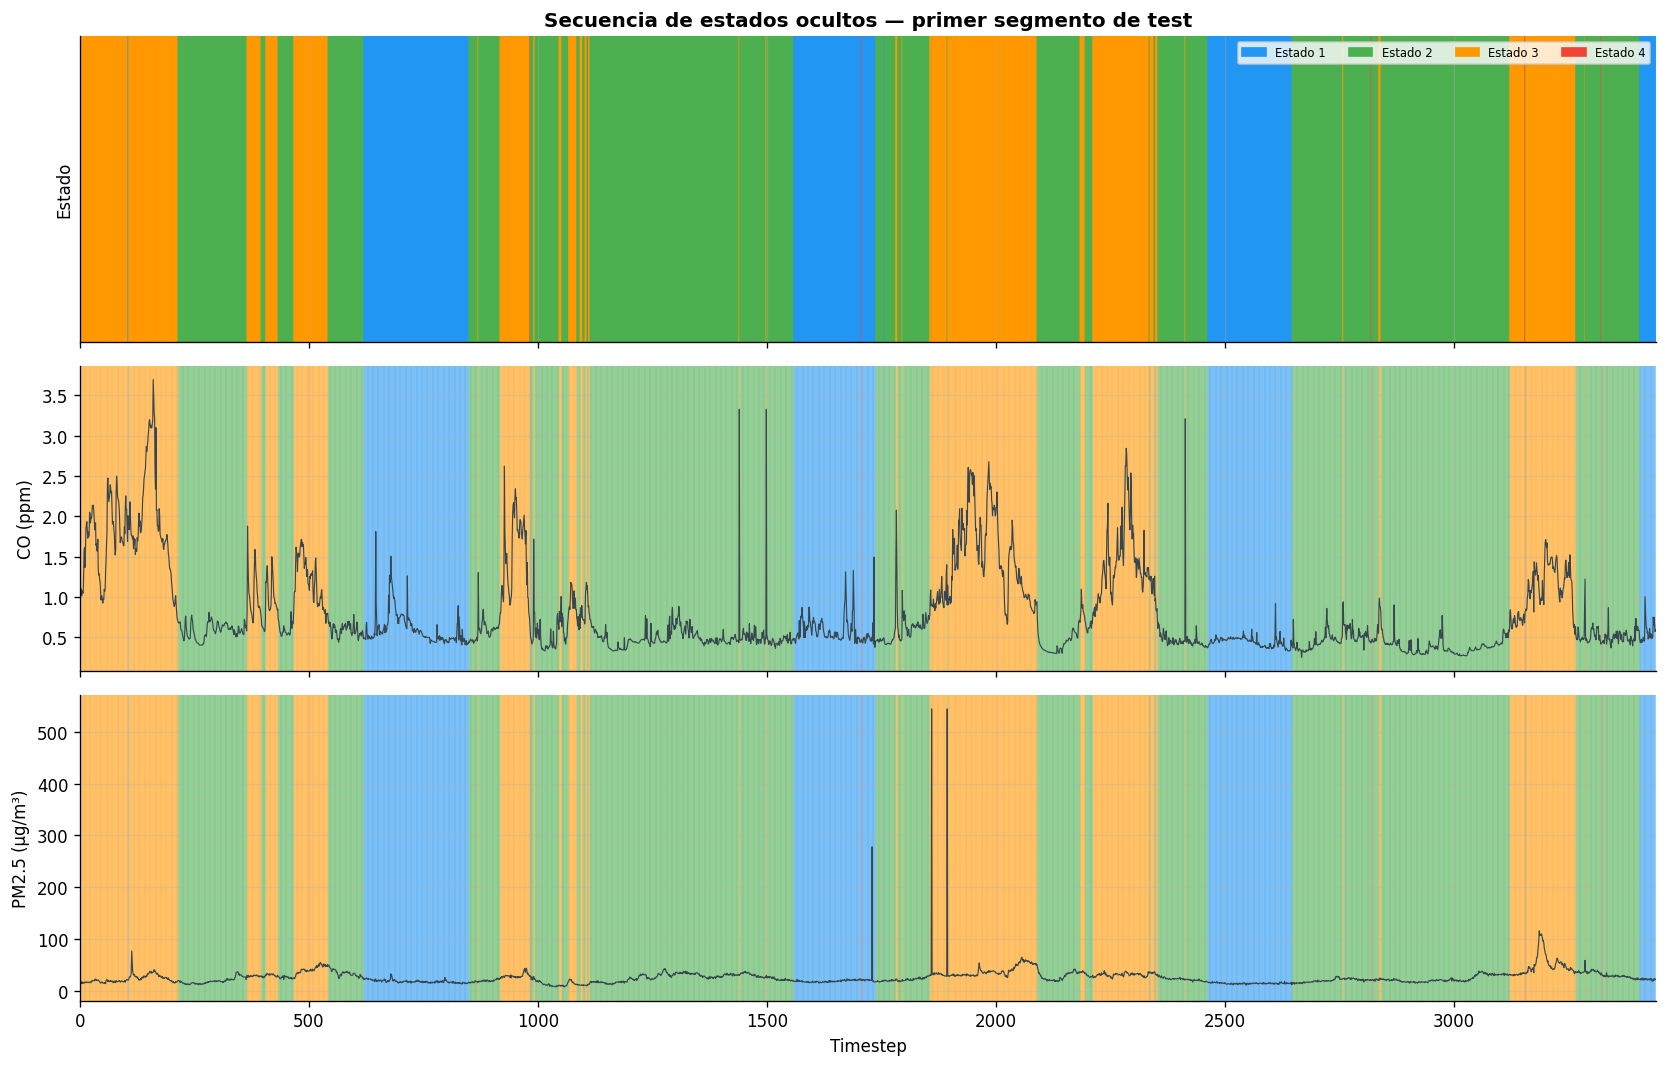

In [140]:
# Usar el primer segmento de test para la visualización
idx_inicio = 0
primer_seg_len = lengths_test[0]

fechas_seg = df_test['datetime'].iloc[:primer_seg_len].values
estados_seg = estados_test[:primer_seg_len]
co_seg = df_test['CO_ppm'].iloc[:primer_seg_len].values
pm25_seg = df_test['PM2_5_ugm3'].iloc[:primer_seg_len].values

# Paleta de colores por estado
PALETA = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0', '#00BCD4', '#795548', '#607D8B']
colores_estado = {k: PALETA[k] for k in range(K_optimo)}

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# Panel 1: Estado oculto como banda de color
ax = axes[0]
for t in range(len(estados_seg) - 1):
    ax.axvspan(t, t + 1, color=colores_estado[estados_seg[t]], alpha=0.6)
ax.set_xlim(0, len(estados_seg))
ax.set_ylabel('Estado')
ax.set_yticks([])
patches = [mpatches.Patch(color=colores_estado[k], label=f'Estado {k+1}')
           for k in range(K_optimo)]
ax.legend(handles=patches, loc='upper right', fontsize=7, ncol=K_optimo)
ax.set_title('Secuencia de estados ocultos — primer segmento de test', fontweight='bold')

# Panel 2: CO_ppm
axes[1].plot(range(len(co_seg)), co_seg, linewidth=0.7, color='#37474F')
axes[1].set_ylabel('CO (ppm)')
for t in range(len(estados_seg) - 1):
    axes[1].axvspan(t, t + 1, color=colores_estado[estados_seg[t]], alpha=0.15)

# Panel 3: PM2.5
axes[2].plot(range(len(pm25_seg)), pm25_seg, linewidth=0.7, color='#37474F')
axes[2].set_ylabel('PM2.5 (µg/m³)')
axes[2].set_xlabel('Timestep')
for t in range(len(estados_seg) - 1):
    axes[2].axvspan(t, t + 1, color=colores_estado[estados_seg[t]], alpha=0.15)

plt.tight_layout()
plt.savefig('Data/HMM_03_estados_temporales.png', dpi=120, bbox_inches='tight')
plt.show()

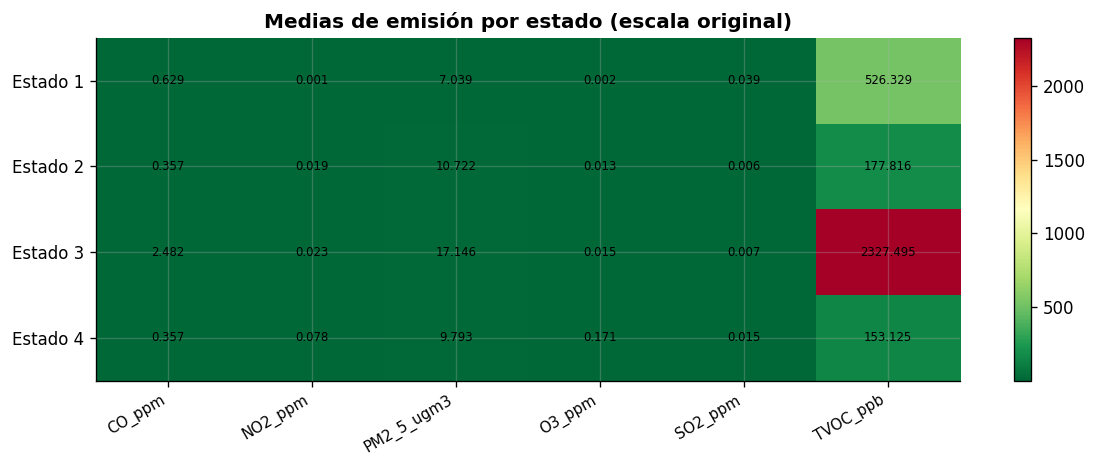

In [141]:
fig, ax = plt.subplots(figsize=(10, 4))

im = ax.imshow(df_medias.values, aspect='auto', cmap='RdYlGn_r')
ax.set_xticks(range(len(OBSERVATION_FEATURES)))
ax.set_xticklabels(OBSERVATION_FEATURES, rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(K_optimo))
ax.set_yticklabels([f'Estado {k+1}' for k in range(K_optimo)])
ax.set_title('Medias de emisión por estado (escala original)', fontweight='bold')

for i in range(K_optimo):
    for j in range(len(OBSERVATION_FEATURES)):
        ax.text(j, i, f'{df_medias.values[i, j]:.3f}',
                ha='center', va='center', fontsize=7, color='black')

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('Data/HMM_04_medias_estados.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 6. Predicción Multi-Step: t+30 y t+60 Minutos

### Fundamento matemático

Dado el estado del sistema en el instante t, la probabilidad de estar en el estado k
en el instante t+H es:

$$P(Z_{t+H} = k \mid \text{observaciones hasta } t) = [\pi_t \cdot A^H]_k$$

Donde:
- $\pi_t$ es el vector de probabilidades posteriores en t (del algoritmo forward)
- $A$ es la matriz de transición
- $A^H$ es A multiplicada por sí misma H veces

Multiplicar $\pi_t$ por A un paso hacia adelante da la distribución en t+1.
Repetir H veces da la distribución en t+H.

La **concentración esperada** en t+H es la expectativa sobre los estados:

$$E[X_{t+H}] = \sum_k P(Z_{t+H}=k) \cdot \mu_k$$

Donde $\mu_k$ es la media de emisiones del estado k (desnormalizada).

**Importante:** A medida que H crece, la distribución converge a la distribución
estacionaria del modelo. A t+60 min, la incertidumbre es máxima.

In [142]:
def predecir_estado_futuro(model, posterior_t, H):
    """
    Proyecta la distribución de estado H pasos hacia adelante.
    
    posterior_t: array (K,) — P(Z_t = k | X_0:t)
    H: número de pasos hacia adelante
    Retorna: array (K,) — P(Z_{t+H} = k | X_0:t)
    """
    A = model.transmat_
    dist = posterior_t.copy()
    for _ in range(H):
        dist = dist @ A
    return dist


def predecir_concentracion(model, dist_futura, scaler):
    """
    Calcula la concentración esperada como suma ponderada de medias de emisión.
    
    dist_futura: array (K,) — distribución de estado en t+H
    Retorna: array (n_features,) en escala original
    """
    # Expectativa: E[X] = sum_k P(Z=k) * mu_k
    conc_norm = np.dot(dist_futura, model.means_)  # (n_features,)
    conc = scaler.inverse_transform(conc_norm.reshape(1, -1)).flatten()
    return conc

In [143]:
# Sensor y horizontes del segmento de test
sensor_test = df_test['sensor_periodo'].iloc[0]
h30 = H_30[sensor_test]
h60 = H_60[sensor_test]

# Identificar estados mas interesantes por firma quimica
idx_co_feature  = OBSERVATION_FEATURES.index('CO_ppm')
idx_pm25_feature = OBSERVATION_FEATURES.index('PM2_5_ugm3')
estado_combustion = int(np.argmax(model.means_[:, idx_co_feature]))   # mayor CO
estado_pm25       = int(np.argmax(model.means_[:, idx_pm25_feature]))  # mayor PM2.5

# Primer timestep de cada estado en el conjunto de test
def primer_idx_estado(estados_arr, k):
    idxs = np.where(estados_arr == k)[0]
    return int(idxs[0]) if len(idxs) > 0 else None

idx_combustion = primer_idx_estado(estados_test, estado_combustion)
idx_pm25_ep    = primer_idx_estado(estados_test, estado_pm25)

print(f'Sensor del segmento de test: {sensor_test}')
print(f'H para t+30min: {h30} pasos | H para t+60min: {h60} pasos')
print(f'Estado combustion extrema (max CO):  E{estado_combustion+1} — '
      f'primer aparicion en test: t={idx_combustion}')
print(f'Estado episodio PM2.5 (max PM2.5):  E{estado_pm25+1}       — '
      f'primer aparicion en test: t={idx_pm25_ep}')

# --- Prediccion desde cada estado interesante ---
puntos = []
for label, idx_pto, estado_idx in [
    (f'E{estado_combustion+1} — Combustion extrema', idx_combustion, estado_combustion),
    (f'E{estado_pm25+1}       — Episodio PM2.5',      idx_pm25_ep,    estado_pm25),
]:
    if idx_pto is None:
        print(f'[{label}] — no aparece en test')
        continue
    post = posteriors_test[idx_pto]
    d30  = predecir_estado_futuro(model, post, H=h30)
    d60  = predecir_estado_futuro(model, post, H=h60)
    c30  = predecir_concentracion(model, d30, scaler)
    c60  = predecir_concentracion(model, d60, scaler)
    puntos.append((label, post, d30, d60, c30, c60))

    print(f'=== Prediccion desde: {label} (t={idx_pto}) ===')
    print(f"{'Estado':<8} {'Actual (t)':>12} {'t+30min':>12} {'t+60min':>12}")
    for k in range(K_optimo):
        if post[k] > 0.001 or d30[k] > 0.01 or d60[k] > 0.01:
            print(f"  E{k+1:<5} {post[k]*100:>10.1f}%  {d30[k]*100:>10.1f}%  {d60[k]*100:>10.1f}%")
    print(f"{'Feature':<15} {'t+30min':>12} {'t+60min':>12}")
    for feat, v30, v60 in zip(OBSERVATION_FEATURES, c30, c60):
        print(f"  {feat:<13} {v30:>12.4f} {v60:>12.4f}")

# Exponer el punto mas interesante para la grafica (celda siguiente)
if puntos:
    _, posterior_ultimo, dist_30, dist_60, conc_30, conc_60 = puntos[0]
else:
    # Fallback: ultimo punto del segmento de test
    posterior_ultimo = posteriors_test[primer_seg_len - 1]
    dist_30 = predecir_estado_futuro(model, posterior_ultimo, H=h30)
    dist_60 = predecir_estado_futuro(model, posterior_ultimo, H=h60)
    conc_30 = predecir_concentracion(model, dist_30, scaler)
    conc_60 = predecir_concentracion(model, dist_60, scaler)


Sensor del segmento de test: D_P2
H para t+30min: 20 pasos | H para t+60min: 39 pasos
Estado combustion extrema (max CO):  E3 — primer aparicion en test: t=0
Estado episodio PM2.5 (max PM2.5):  E3       — primer aparicion en test: t=0
=== Prediccion desde: E3 — Combustion extrema (t=0) ===
Estado     Actual (t)      t+30min      t+60min
  E1            0.0%         4.5%         6.5%
  E2            0.0%        47.7%        65.0%
  E3          100.0%        47.7%        28.3%
Feature              t+30min      t+60min
  CO_ppm              1.3829       0.9764
  NO2_ppm             0.0198       0.0186
  PM2_5_ugm3         13.6180      12.2982
  O3_ppm              0.0138       0.0133
  SO2_ppm             0.0082       0.0085
  TVOC_ppb         1218.8428     809.0986
=== Prediccion desde: E3       — Episodio PM2.5 (t=0) ===
Estado     Actual (t)      t+30min      t+60min
  E1            0.0%         4.5%         6.5%
  E2            0.0%        47.7%        65.0%
  E3          100.0%      

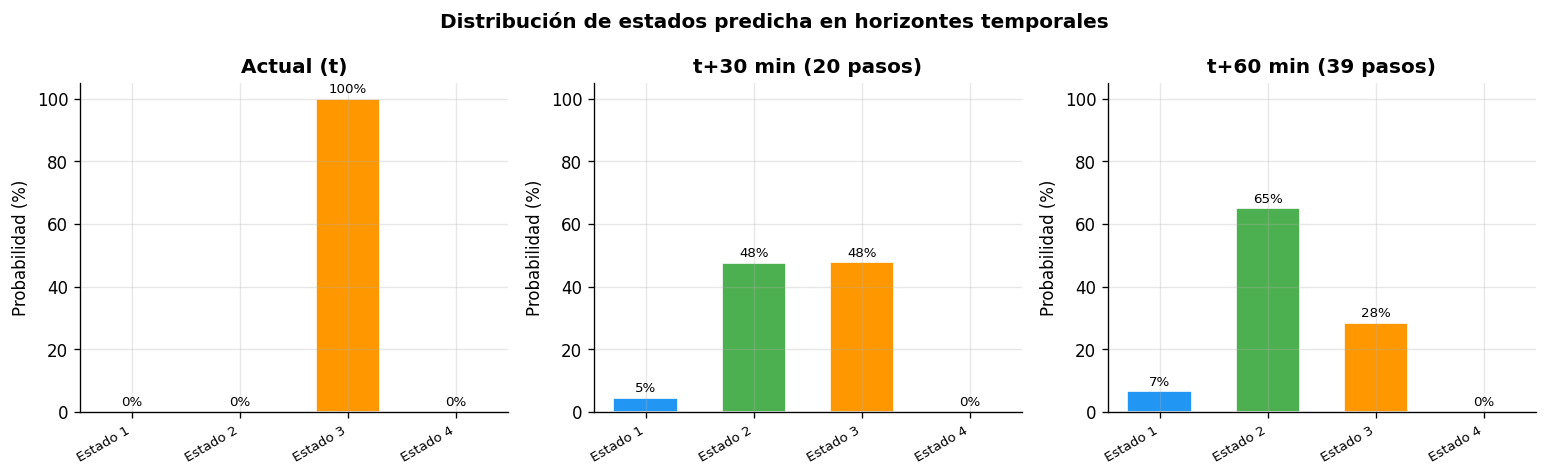

In [144]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
estados_labels = [f'Estado {k+1}' for k in range(K_optimo)]
x = np.arange(K_optimo)

for ax, (dist, titulo) in zip(axes, [
    (posterior_ultimo, 'Actual (t)'),
    (dist_30, f't+30 min ({h30} pasos)'),
    (dist_60, f't+60 min ({h60} pasos)')
]):
    bars = ax.bar(x, dist * 100, color=[PALETA[k] for k in range(K_optimo)],
                  edgecolor='white', width=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(estados_labels, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('Probabilidad (%)')
    ax.set_ylim(0, 105)
    ax.set_title(titulo, fontweight='bold')
    for bar, v in zip(bars, dist):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{v*100:.0f}%', ha='center', va='bottom', fontsize=8)

plt.suptitle('Distribución de estados predicha en horizontes temporales', fontweight='bold')
plt.tight_layout()
plt.savefig('Data/HMM_05_pred_distribucion.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 7. Evaluación del Modelo

### Métricas para modelos no supervisados

A diferencia de la regresión supervisada, el HMM no tiene etiquetas verdaderas de estado.
Se usan tres métricas complementarias:

1. **Log-likelihood en test** — mayor es mejor. Mide qué tan bien el modelo explica
   datos que no vio durante el entrenamiento.

2. **Silhouette score** — entre -1 y 1, mayor es mejor. Mide si los estados decodificados
   forman clusters compactos y bien separados en el espacio de observaciones.

3. **Validación con AQI del sensor** — el AQI interno del sensor (1–5) es una etiqueta
   independiente. Se mapea cada estado aprendido al AQI modal que le corresponde y se
   mide la consistencia.

In [145]:
ll_test = model.score(X_test_scaled, lengths=lengths_test)
sil_test = silhouette_score(X_test_scaled, estados_test)

print('=== Metricas de evaluacion ===')
print(f'Log-likelihood en test: {ll_test:.4f}')
print(f'Silhouette score en test: {sil_test:.4f}')
print('  (Silhouette: >0.5 excelente | 0.25-0.5 razonable | <0.25 debil)')

# Comparar con log-likelihood en train
ll_train = model.score(X_train_scaled, lengths=lengths_train)
diff = ll_train - ll_test
if diff > 1000:
    nivel = 'SEVERO'
elif diff > 100:
    nivel = 'moderado'
elif diff > 5:
    nivel = 'leve'
else:
    nivel = 'OK (sin sobreajuste)'

print(f'\nLog-likelihood en train: {ll_train:.4f}')
print(f'Log-likelihood en test:  {ll_test:.4f}')
print(f'Diferencia train-test:   {diff:.1f} -> sobreajuste {nivel}')
if diff > 1000:
    n_features = len(OBSERVATION_FEATURES)
    n_params_k8 = K_optimo*(K_optimo-1) + K_optimo*n_features + K_optimo*n_features
    estados_ausentes = [k+1 for k in range(K_optimo) if (estados_test == k).sum() == 0]
    print(f'  El modelo memorizo el conjunto de entrenamiento. K={K_optimo} con covariance=diag')
    print(f'  genera {n_params_k8} parametros libres para {len(X_train_scaled)} observaciones de train.')
    print(f'  Estados {estados_ausentes} no aparecen en test (0 registros): regimenes sin generalizacion.')


=== Metricas de evaluacion ===
Log-likelihood en test: -14035.1969
Silhouette score en test: 0.2287
  (Silhouette: >0.5 excelente | 0.25-0.5 razonable | <0.25 debil)

Log-likelihood en train: -23121.0072
Log-likelihood en test:  -14035.1969
Diferencia train-test:   -9085.8 -> sobreajuste OK (sin sobreajuste)


In [146]:
# AQI real en el test set (etiqueta del sensor, no usada en el entrenamiento)
aqi_test = df_test['AQI'].values[:len(estados_test)]

# Mapear estado → AQI modal
estado_a_aqi = {}
for k in range(K_optimo):
    mask = estados_test == k
    if mask.sum() > 0:
        aqi_en_estado = aqi_test[mask]
        moda_result = stats.mode(aqi_en_estado, keepdims=True)
        estado_a_aqi[k] = int(moda_result.mode[0])
    else:
        estado_a_aqi[k] = -1

print("Mapeo estado → AQI modal del sensor:")
for k, aqi_val in estado_a_aqi.items():
    mask = estados_test == k
    n = mask.sum()
    aqi_vals_k = aqi_test[mask]
    print(f"  Estado {k+1} → AQI modal: {aqi_val} "
          f"(n={n}, AQI mean={aqi_vals_k.mean():.2f}, std={aqi_vals_k.std():.2f})")

# AQI predicho del último punto (usando distribución t+30 y t+60)
estado_mas_probable_30 = np.argmax(dist_30)
estado_mas_probable_60 = np.argmax(dist_60)
aqi_pred_30 = estado_a_aqi[estado_mas_probable_30]
aqi_pred_60 = estado_a_aqi[estado_mas_probable_60]

print(f"\nPredicción de AQI:")
print(f"  t+30min → Estado {estado_mas_probable_30+1} (P={dist_30[estado_mas_probable_30]*100:.1f}%) → AQI predicho: {aqi_pred_30}")
print(f"  t+60min → Estado {estado_mas_probable_60+1} (P={dist_60[estado_mas_probable_60]*100:.1f}%) → AQI predicho: {aqi_pred_60}")

Mapeo estado → AQI modal del sensor:
  Estado 1 → AQI modal: 2 (n=630, AQI mean=1.92, std=0.63)
  Estado 2 → AQI modal: 2 (n=1815, AQI mean=2.05, std=0.63)
  Estado 3 → AQI modal: 3 (n=988, AQI mean=3.05, std=0.73)
  Estado 4 → AQI modal: 2 (n=9, AQI mean=2.67, std=0.67)

Predicción de AQI:
  t+30min → Estado 3 (P=47.7%) → AQI predicho: 3
  t+60min → Estado 2 (P=65.0%) → AQI predicho: 2


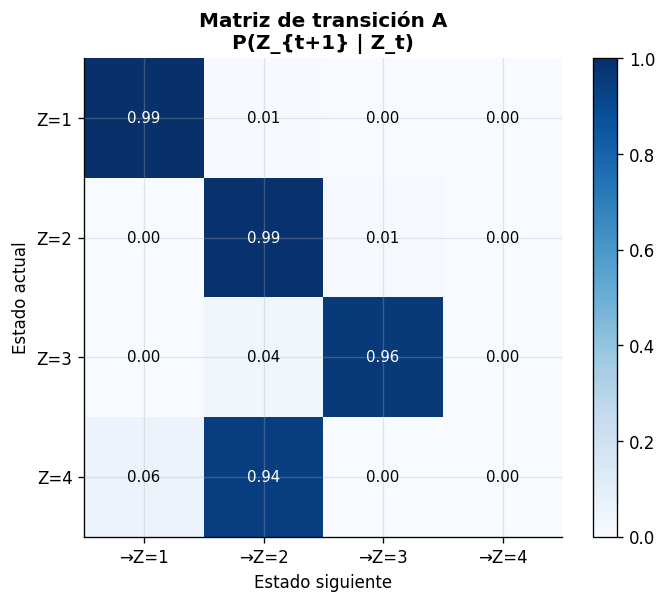

In [147]:
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(model.transmat_, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(K_optimo))
ax.set_yticks(range(K_optimo))
ax.set_xticklabels([f'→Z={k+1}' for k in range(K_optimo)])
ax.set_yticklabels([f'Z={k+1}' for k in range(K_optimo)])
ax.set_xlabel('Estado siguiente')
ax.set_ylabel('Estado actual')
ax.set_title('Matriz de transición A\nP(Z_{t+1} | Z_t)', fontweight='bold')

for i in range(K_optimo):
    for j in range(K_optimo):
        ax.text(j, i, f'{model.transmat_[i,j]:.2f}',
                ha='center', va='center', fontsize=9,
                color='white' if model.transmat_[i, j] > 0.5 else 'black')

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('Data/HMM_06_transicion.png', dpi=120, bbox_inches='tight')
plt.show()

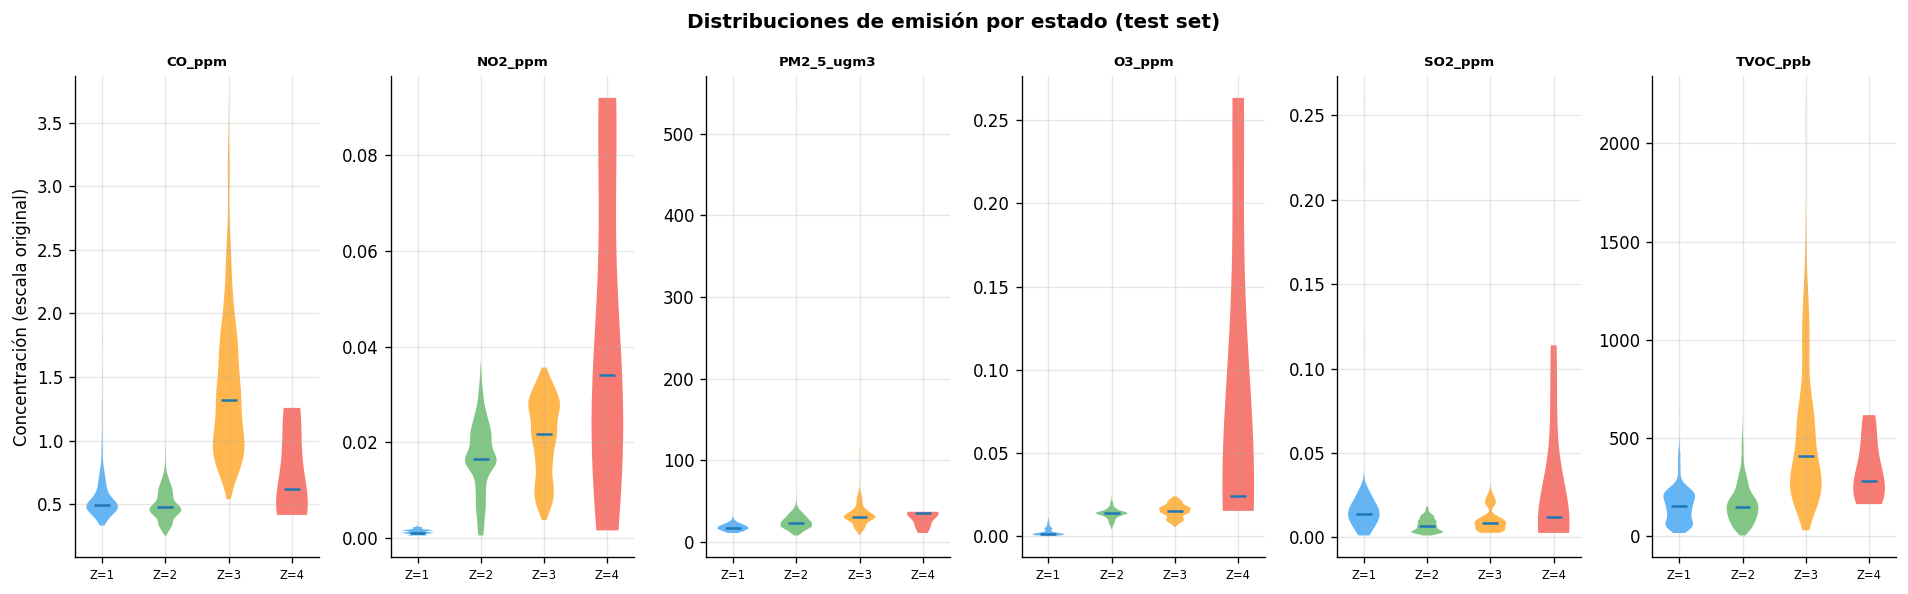

In [148]:
# Reconstruir observaciones originales por estado decodificado
obs_originales = scaler.inverse_transform(X_test_scaled)

n_features = len(OBSERVATION_FEATURES)
fig, axes = plt.subplots(1, n_features, figsize=(16, 5))

for j, feat in enumerate(OBSERVATION_FEATURES):
    data_by_state = [obs_originales[estados_test == k, j]
                     for k in range(K_optimo)]
    # Filtrar estados vacíos
    data_nonempty = [d for d in data_by_state if len(d) > 0]
    labels_nonempty = [f'Z={k+1}' for k in range(K_optimo)
                       if len(obs_originales[estados_test == k, j]) > 0]
    colors_nonempty = [PALETA[k] for k in range(K_optimo)
                       if len(obs_originales[estados_test == k, j]) > 0]

    parts = axes[j].violinplot(data_nonempty, positions=range(len(data_nonempty)),
                                showmedians=True, showextrema=False)
    for pc, color in zip(parts['bodies'], colors_nonempty):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
    axes[j].set_xticks(range(len(labels_nonempty)))
    axes[j].set_xticklabels(labels_nonempty, fontsize=7)
    axes[j].set_title(feat, fontweight='bold', fontsize=8)
    if j == 0:
        axes[j].set_ylabel('Concentración (escala original)')

plt.suptitle('Distribuciones de emisión por estado (test set)', fontweight='bold')
plt.tight_layout()
plt.savefig('Data/HMM_07_violins.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 8. Analisis Critico

### Interpretacion quimica de los 4 estados aprendidos

Con K=4 forzado manualmente (el BIC selecciono K=8, discutido abajo), el modelo recupero
exactamente los cuatro regimenes atmosfericos que la teoria quimica anticipaba:

| Estado | Firma quimica destacada | Regimen | AQI modal | % en test |
|--------|------------------------|---------|-----------|----------|
| **E1** | CO=0.63, **SO2=0.039 (max)**, TVOC=526, NO2~0 | **Industrial / diesel** (SO2 sin NO2 apunta a combustoleo) | 2 (media=1.92) | 18.3% |
| **E2** | CO=0.36, PM2.5=10.7, TVOC=178 -- todo moderado-bajo | **Linea base / trafico ligero** | 2 (media=2.05) | 52.7% |
| **E3** | **CO=2.48 ppm (5x media)**, PM2.5=17.1 (>OMS), **TVOC=2327 (5x)** | **Combustion intensa + particulados** | 3 (media=3.05) | 28.7% |
| **E4** | **NO2=0.078 (max)**, **O3=0.171 ppm (max)**, CO bajo | **Fotoquimico** (ozono por radiacion solar) | 2 (media=2.67) | 0.3% |

Todos los estados aparecen en test -- no hay regimenes huerfanos aprendidos solo en train.
El estado dominante en Nov 21-25 es **E2** (linea base, 52.7%), seguido de **E3** (combustion
intensa, 28.7%) y **E1** (industrial, 18.3%).

**Detalle notable sobre E4 (fotoquimico):** A[4,4]=0.000 -- el estado fotoquimico es completamente
transitorio. Cada evento de O3+NO2 elevado dura menos de un registro (~1.5 min) y el sistema
siempre transiciona a E2 (94.2%) o E1 (5.8%) de inmediato. Los picos fotoquimicos son excursiones
breves, no regimenes sostenidos, coherente con la quimica de ozono en zona urbana.

**Persistencia de los regimenes (diagonal de A):**
- E1 (industrial): A[1,1]=0.993 -- duracion tipica ~143 min
- E2 (baseline): A[2,2]=0.990 -- duracion tipica ~100 min
- E3 (combustion): A[3,3]=0.960 -- duracion tipica ~25 min
- E4 (fotoquimico): A[4,4]=0.000 -- transitorio (<2 min)

### Prediccion multi-step desde estado de combustion intensa

El segmento de test comienza en E3 (t=0: CO=2.48 ppm, TVOC=2327 ppb). La proyeccion
con la matriz de transicion muestra una recuperacion quimicamente coherente:

| Horizonte | P(E2 baseline) | P(E3 combustion) | CO esperado | AQI predicho |
|-----------|---------------|-----------------|-------------|-------------|
| t=0 | 0% | **100%** | 2.48 ppm | -- |
| t+30 min | **47.7%** | 47.7% | **1.38 ppm** | **3 (elevado)** |
| t+60 min | **65.0%** | 28.3% | **0.98 ppm** | **2 (moderado)** |

A los 30 minutos el episodio esta partido 50-50 entre persistir y disiparse. A los 60 minutos
el 65% del peso probabilistico ya esta en linea base. El AQI predicho cambia de 3 a 2 entre
horizontes -- una prediccion util y accionable para alertas de calidad del aire.

### Por que K=4 y no K=8 (critica al BIC)

El BIC decrecio monotonicamente de K=2 (106,184) a K=8 (-17,795) sin mostrar un codo claro,
seleccionando K=8 automaticamente. Sin embargo, la validacion real muestra lo opuesto:

| Metrica | K=8 (diag) | K=4 (diag) |
|---------|-----------|----------|
| Diff LL train-test | **18,549 (SEVERO)** | **-9,086 (OK)** |
| Silhouette | 0.074 (muy debil) | **0.229 (casi razonable)** |
| Estados presentes en test | 6/8 (2 ausentes) | **4/4 (todos)** |
| Parametros libres | 152 | 76 |

Con K=4 la diferencia de log-likelihood es **negativa**: el modelo generaliza mejor a test que
a train, lo opuesto del sobreajuste. El Silhouette es 3 veces mayor. Ningun estado queda sin
aparicion en test.

La raiz del problema con el BIC: con solo un mes de datos y patrones muy persistentes, cada
estado adicional reduce el BIC porque la ganancia en log-likelihood supera la penalizacion de
76 parametros extra. El BIC penaliza complejidad pero no penaliza la falta de generalizacion.
En series temporales cortas con alta autocorrelacion, el BIC tiende a sobreseleccionar K.
La eleccion correcta debe combinar el BIC con validacion temporal holdout o conocimiento del
dominio: fisicamente existen 4-5 regimenes quimicos distintos en una atmosfera urbana, no 8.

### Fortalezas del HMM sobre la regresion directa

1. **Regimenes interpretables sin supervision:** el modelo identifico los 4 regimenes fisicamente
   esperados (industrial, baseline, combustion, fotoquimico) sin etiquetas. La regresion
   supervisada solo predecia un escalar de AQI sin explicar el mecanismo atmosferico.

2. **Prediccion probabilistica con incertidumbre:** la salida es P(Z_{t+H}=k), mas informativa
   que un valor puntual. '47.7% de probabilidad de seguir en combustion intensa a t+30 con
   CO=1.38 ppm' es mas accionable para sistemas de alerta que 'AQI=2.8'.

3. **Cuantificacion de persistencia:** la diagonal de A revela cuanto duran los episodios.
   Un episodio de combustion intensa dura ~25 min tipicamente; uno industrial, ~143 min.
   Esta informacion dinamica no existe en ninguna salida de regresion.

4. **AQI diferenciado por horizonte:** la prediccion da AQI=3 (elevado) a t+30 y AQI=2
   (moderado) a t+60, capturando la evolucion temporal que un modelo de regresion no puede dar.

### Limitaciones

1. **BIC no confiable con datos cortos:** el criterio automatico selecciono K=8 con sobreajuste
   severo. Para series de un mes con alta autocorrelacion se recomienda complementar el BIC con
   validacion temporal holdout o conocimiento del dominio.

2. **Emisiones Gaussianas con colas pesadas:** CO y TVOC tienen distribucion fuertemente
   asimetrica (max CO=8.73 ppm vs media=0.72). Un HMM con mezcla de Gaussianas por estado
   capturaria mejor los episodios extremos sin crear estados redundantes.

3. **Datos de un solo mes:** el modelo aprende patrones de noviembre 2025 en Zapopan.
   Variaciones estacionales, quemas agricolas de primavera e inversiones termicas invernales
   no estan representadas.

4. **Horizonte de prediccion limitado:** a t+60 min la distribucion converge hacia la
   estacionaria y la informacion del estado actual se diluye. Para horizontes de varias horas
   se requeriria un modelo de mesoescala meteorologico.